In [1]:
import pandas as pd
import numpy as np
import os

"""EXAMPLE USAGE FOR NOTEBOOKS"""

path_mixed_demographics = "../data/training_data/mixed_demographics.csv"
path_all_files = "../data/training_data/mixed_samples"

mixed_demographics_df = pd.read_csv(path_mixed_demographics, index_col=0)

onlyfiles = [
    os.path.join(path_all_files, f) 
    for f in os.listdir(path_all_files)
    if f.endswith("npy")
]

all_samples = np.empty([900, 10, 18000, 4])
for i, file_name in enumerate(onlyfiles):
    all_samples[i] = np.load(file_name)

In [12]:
print(all_samples[0].shape)
print(all_samples[0][0][1])
print(mixed_demographics_df.columns.tolist())

(10, 18000, 4)
[-16.27009583  14.77843094   7.31107855   2.        ]
['MI', 'age', 'BMI', 'height', 'weight', 'diastolic_BP', 'systolic_BP', 'sex']


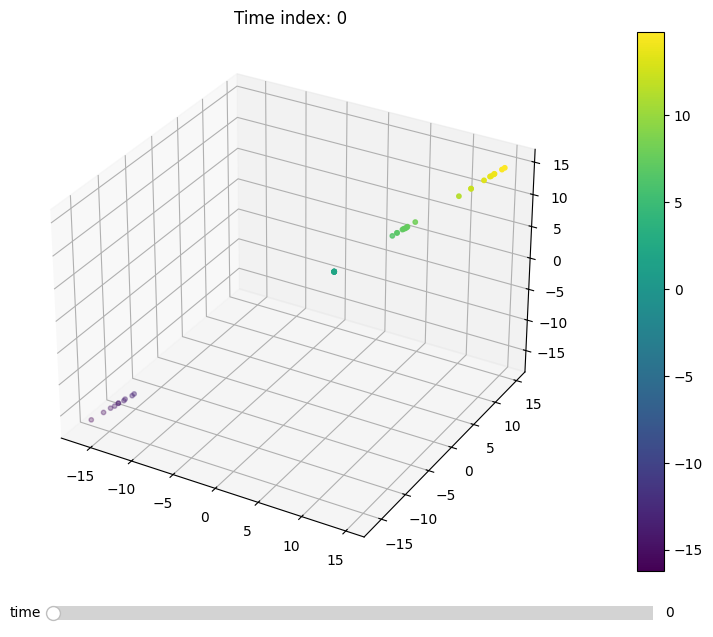

In [15]:
# Matplotlib + Slider (3D)
# In a Jupyter notebook, run: %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D       # noqa: F401 (for 3D projection)
from matplotlib.widgets import Slider

# Example: all_samples is numpy array with shape (10, 16000, 4)
# all_samples[t][i] -> [x,y,z,c]
# We'll assume `all_samples` already exists in your namespace.

n_time = all_samples.shape[0]  # should be 10

# initial time index
t0 = 0
x = all_samples[t0, :, 0]
y = all_samples[t0, :, 1]
z = all_samples[t0, :, 2]
c = all_samples[t0, :, 3]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=c, cmap='viridis', s=10)  # adjust s for marker size
cb = fig.colorbar(sc, ax=ax, pad=0.1)
ax.set_title(f'Time index: {t0}')

# slider axes: [left, bottom, width, height] in figure coords
ax_slider = plt.axes([0.20, 0.03, 0.60, 0.04])
slider = Slider(ax_slider, 'time', 0, n_time - 1, valinit=t0, valstep=1)

def update(val):
    t = int(slider.val)
    x = all_samples[t, :, 0]
    y = all_samples[t, :, 1]
    z = all_samples[t, :, 2]
    c = all_samples[t, :, 3]

    # update 3D offsets
    sc._offsets3d = (x, y, z)

    # update colors
    sc.set_array(c)              # update color array for the PathCollection
    # If color range changes across times, you might want to reset vmin/vmax:
    # sc.set_clim(vmin=c.min(), vmax=c.max())

    ax.set_title(f'Time index: {t}')
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()


When loading the data from a patient, the shape of the numpy array is (10, 18000, 4). 
*First dimension: time (10 frames per sample recorded
*Second dimension: individual points in the pointcloud (18000 points per heart)
*Third dimension: the (x,y,z) coordinates for a point, as well as a sub-structure label


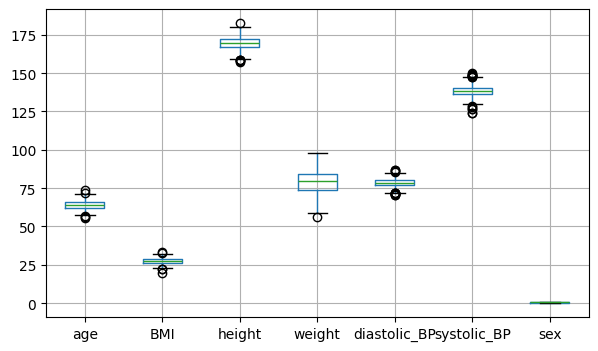

In [14]:
plt.figure(figsize=(7,4))
boxplot = mixed_demographics_df.boxplot()